### Análise de Sentimento do Twitter

Este projeto aplica técnicas de Análise de Sentimento (AS) e Processamento de Linguagem Natural (PLN) para classificar tweets do Kaggle com base em seu conteúdo.

**Dados**

O conjunto de dados, obtido do X (anteriormente Twitter) no Kaggle, contém dados de treino e validação com as seguintes variáveis:

*   **Twitter ID**: ID do comentário
*   **Entity**: Empresa mencionada
*   **Target**: Sentimento do comentário (variável alvo)
*   **content**: Conteúdo do comentário

**Objetivo**

Desenvolver um modelo de Aprendizado de Máquina para classificar automaticamente o sentimento dos tweets. Inclui análise exploratória para extrair insights.

**Modelagem**

Será utilizada a biblioteca NLTK para pré-processamento textual.

## Exploração Inicial dos Dados

In [1]:
import pandas as pd

# Definindo os nomes das colunas para o DataFrame
cols=['tweetid', 'entity', 'target', 'content']

# Carregando o arquivo CSV em um DataFrame pandas, especificando os nomes das colunas
df_twitter = pd.read_csv('twitter_training.csv', names=cols)

# Exibindo as primeiras 5 linhas do DataFrame para uma inspeção inicial
df_twitter.head()

,tweetid,entity,target,content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### Verificação das Colunas

Para entender melhor a estrutura do nosso DataFrame, vamos exibir os nomes de todas as colunas presentes.

In [2]:
# Verificando os nomes das colunas do DataFrame
df_twitter.columns

Index(['tweetid', 'entity', 'target', 'content'], dtype='object')

### Informações Gerais do DataFrame e Detalhes das Colunas

Utilizamos o método `.info()` para obter um resumo conciso do DataFrame, incluindo o número de entradas, o número de colunas, o tipo de dados de cada coluna e a quantidade de valores não nulos. Conforme o resultado, observamos que o DataFrame possui 74682 entradas e 4 colunas. A coluna 'content' apresenta 73996 valores não nulos, indicando a presença de valores ausentes que precisarão ser tratados. As colunas 'tweetid' e 'entity' são do tipo inteiro (int64) e objeto (object), respectivamente, enquanto 'target' e 'content' são do tipo objeto (object).

In [3]:
# Exibindo informações gerais sobre o DataFrame, incluindo tipos de dados e valores não nulos
df_twitter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tweetid  74682 non-null  int64 
 1   entity   74682 non-null  object
 2   target   74682 non-null  object
 3   content  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Empresas Mencionadas nos Tweets

Para termos uma ideia das entidades (empresas) que são mencionadas nos tweets, exibimos a lista de valores únicos presentes na coluna `entity`.

In [4]:
# Exibindo os valores únicos da coluna 'entity' para ver quais empresas foram mencionadas
df_twitter['entity'].unique()

array(['Borderlands', 'CallOfDutyBlackopsColdWar', 'Amazon', 'Overwatch',
       'Xbox(Xseries)', 'NBA2K', 'Dota2', 'PlayStation5(PS5)',
       'WorldOfCraft', 'CS-GO', 'Google', 'AssassinsCreed', 'ApexLegends',
       'LeagueOfLegends', 'Fortnite', 'Microsoft', 'Hearthstone',
       'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)', 'Verizon',
       'HomeDepot', 'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty',
       'TomClancysRainbowSix', 'Facebook', 'GrandTheftAuto(GTA)',
       'MaddenNFL', 'johnson&johnson', 'Cyberpunk2077',
       'TomClancysGhostRecon', 'Nvidia'], dtype=object)

### Verificação das Variáveis da Coluna Alvo

Agora, vamos verificar os valores únicos presentes na coluna `target`. Esta coluna representa o sentimento associado a cada tweet, e é a nossa variável alvo para o modelo de análise de sentimento.

In [5]:
# Verificando os valores únicos da coluna 'target'
df_twitter['target'].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

### Verificação de Valores Ausentes (NaNs)

Para identificar se há valores ausentes em nosso DataFrame, utilizamos o método `.isnull().sum()`. O resultado nos mostra a contagem de valores nulos para cada coluna. Conforme a saída, a coluna `content` possui 686 valores ausentes (NaNs), enquanto as outras colunas não apresentam valores nulos.

In [6]:
# Verificando os valores NaN's dos dados
df_twitter.isnull().sum()

,0
tweetid,0
entity,0
target,0
content,686


### Tratamento de Valores Ausentes

Para lidar com os valores ausentes identificados, utilizaremos o método `.dropna()`. Este método remove as linhas que contêm valores nulos no DataFrame. Ao usar `inplace=True`, a modificação é feita diretamente no DataFrame original.

In [7]:
# Removendo as linhas com valores nulos do DataFrame
df_twitter.dropna(inplace=True)

### Confirmando a Remoção dos Valores Ausentes
Após excluir os dados NaN's, percebe-se que nas colunas não existe dados do tipo NaN's

In [8]:
df_twitter.isnull().sum()

,0
tweetid,0
entity,0
target,0
content,0


### Verificação de Dados Duplicados
Verificando se existe twitter duplicados

Contém 2340 ids duplicados


In [9]:
# Verificando twitter duplicados
df_twitter.duplicated().sum()

np.int64(2340)

### Comando para excluir os ids duplicados

In [10]:
#Dropando ids duplicados
df_twitter.drop_duplicates(inplace=True)

### Após excluir os ids duplicados

In [11]:
df_twitter.duplicated().sum()

np.int64(0)

## Análise de Dados

## Análise de Dados

Nesta seção, vamos explorar o conjunto de dados para obter insights importantes sobre o sentimento dos tweets e as empresas mencionadas. Através da visualização de dados, buscaremos responder as seguintes perguntas:

1.  Qual a distribuição de cada sentimento no DataFrame?
2.  Quais empresas receberam mais comentários no Twitter?
3.  Quais empresas possuem mais comentários "Negative"?
4.  Quais empresas receberam mais comentários "Positive"?




In [12]:
#Importação das Bibliotecas para Análise de Dados
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Distribuição de Classes

Para entender como está a distribuição dos sentimentos (classes) no DataFrame, visualizaremos a quantidade de tweets para cada sentimento.

In [13]:
# Obtendo a ordem das classes de sentimento com base na contagem
order = df_twitter['target'].value_counts().index
order

Index(['Negative', 'Positive', 'Neutral', 'Irrelevant'], dtype='object', name='target')

### Distribuição de Classes

Este gráfico de barras exibe a distribuição dos sentimentos (classes) presentes no DataFrame. Cada barra representa um sentimento (`Positive`, `Negative`, `Neutral`, `Irrelevant`) e sua altura indica a frequência, ou seja, a quantidade de tweets associados a esse sentimento. Os valores exatos de frequência são mostrados nos rótulos de cada barra, permitindo uma visualização clara de quais sentimentos são mais ou menos predominantes no conjunto de dados.

 Observamos a seguinte distribuição:
 - Negative (21698)
 - Positive (19713)
 - Neutral (17708)
 - Irrelevant (12537).

<ipython-input-14-4774f1a8148a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(df_twitter, y='target', palette='cubehelix', edgecolor='Black', order=order)


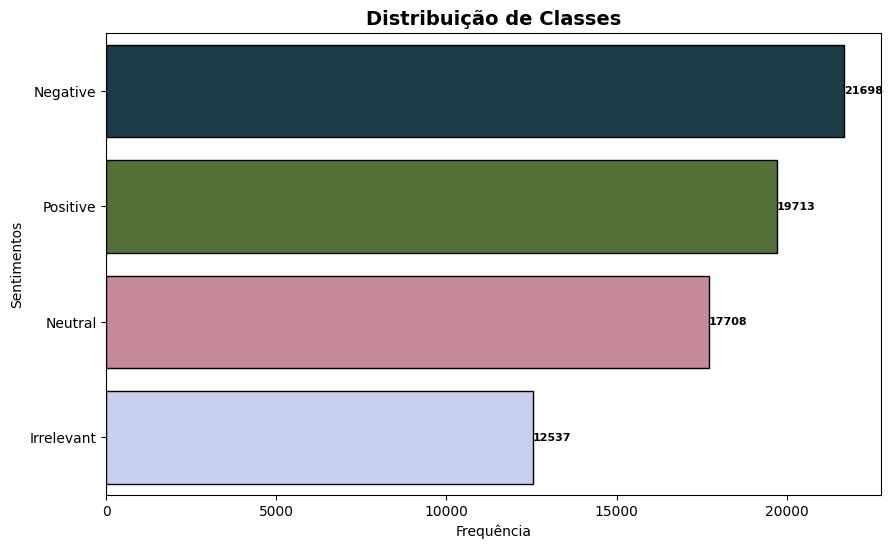

In [14]:
# Criando a figura e os eixos para o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Gerando o gráfico de contagem de sentimentos
ax = sns.countplot(df_twitter, y='target', palette='cubehelix', edgecolor='Black', order=order)

# Adicionando rótulos de dados nas barras para mostrar a contagem exata
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8, fontweight='bold')

# Definindo os rótulos dos eixos e o título do gráfico
ax.set_xlabel("Frequência")
ax.set_ylabel("Sentimentos")
ax.set_title('Distribuição de Classes', fontsize=14, fontweight='bold', color='black')

# Exibindo o gráfico
plt.show()

### Empresas com Mais Comentários

Para identificar quais empresas foram mais comentadas no Twitter, vamos gerar um gráfico que mostra a contagem de tweets para cada entidade.

In [15]:
# Contando a frequência de cada entidade e resetando o índice para um DataFrame
cont_entity = df_twitter['entity'].value_counts().reset_index()

# Renomeando as colunas para clareza
cont_entity.columns =['entity','count']

# Ordenando o DataFrame pela contagem de forma ascendente para o gráfico
cont_entity = cont_entity.sort_values(by='count', ascending=True)

# Criando o gráfico de barras horizontal com Plotly Express
fig = px.bar(cont_entity, y='entity', x='count', orientation='h',
             height=1000)

# Exibindo o gráfico
fig.show()

### Análise de Sentimento por Empresa

Para investigar quais empresas se destacam em termos de comentários negativos e positivos, utilizaremos uma função auxiliar que gera um gráfico de barras para um sentimento específico, mostrando a contagem de comentários por entidade. Isso nos permitirá visualizar rapidamente quais empresas têm uma maior concentração de tweets com determinado sentimento.

In [16]:
def plot_sentiment_by_entity(df, sentiment):
  """
    Gera um gráfico de barras horizontal mostrando a contagem de comentários
    por entidade para um sentimento específico.

    Args:
        df (pd.DataFrame): O DataFrame contendo os dados dos tweets.
        sentiment (str): O sentimento para o qual o gráfico será gerado ('Negative', 'Positive', etc.).

    Returns:
        None: A função exibe o gráfico diretamente e não retorna nenhum valor.
  """

  df_entity_target = df.groupby(['entity', 'target']).size().reset_index(name='count')
  df_plot = df_entity_target[df_entity_target['target'] == sentiment].sort_values(by='count', ascending=True)

  fig = px.bar(df_plot, y='entity', x='count', orientation='h',
                title=f'Top comentários {sentiment.lower()}s',
                color='count')

  fig.update_traces(marker=dict(colorscale='Viridis'), selector=dict(type='bar'))
  fig.update_layout(height=900)
  fig.show()

### Análise das Empresas Mal Comentadas

O gráfico a seguir mostra as entidades (empresas ou  marcas) mais  mals comentadas nos tweets analisados. A visualização foi gerada a partir do agrupamento de tweets por entidade, permitindo identificar quais são os tópicos mais discutidos entre os usuários.


In [17]:
#Execução da Função
plot_sentiment_by_entity(df_twitter, 'Negative')

O gráfico a seguir mostra as entidades (empresas ou  marcas) mais  bens comentadas nos tweets analisados. A visualização foi gerada a partir do agrupamento de tweets por entidade, permitindo identificar quais são os tópicos mais discutidos entre os usuários.

In [18]:
#Executando Função
plot_sentiment_by_entity(df_twitter, 'Positive')

Após essas análises, é possível concluir que a coluna *Entity* e a coluna *Content* possuem uma relação direta e comum.

Isso ocorre porque certas entidades apresentam predominância de determinados tipos de comentários. Essa observação será crucial ao aplicar o pré-processamento dos dados, influenciando a forma como prepararemos as informações para o modelo de Machine Learning.

## Pré-processamento dos dados

In [19]:
#Excluindo a coluna "tweetid" já que não possui relavância para os modelos de machine learning
df_twitter.drop(columns=['tweetid',], axis =1 , inplace = True)
df_twitter.head()

,entity,target,content
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### Importação da biblioteca NTLK
A NLTK (Natural Language Toolkit) é uma das bibliotecas mais populares para trabalhar com Processamento de Linguagem Natural (PLN) em Python. Ela fornece ferramentas e recursos para tratar texto, realizar análise sintática, análise semântica, mineração de textos.

In [20]:
#Instalação da biblioteca NTLK
!pip install nltk

### Pré-processamento Textual com NLTK

Nesta etapa, utilizaremos a biblioteca NLTK para limpar e preparar a coluna 'content' dos tweets. Isso inclui a remoção de stopwords (palavras comuns que não agregam significado, como "o", "a", "é"), pontuações e a aplicação de stemming para reduzir as palavras à sua forma raiz. Essas etapas são essenciais para melhorar a qualidade dos dados textuais antes de alimentar o modelo de machine learning.

In [21]:
#Importação de bibliotecas necessárias para LNP
import nltk
#Aplicação de Stopwords
from nltk.corpus import stopwords
#Aplicação da token
from nltk.tokenize import word_tokenize
#Aplicação do PorterStremmer
from nltk.stem import PorterStemmer
import string
#Stopwords : Irrelevantes para a análise de texto
#Pois ocorrem com frequência em todos os tipos de documentos e não contribuem significativamente para o significado do texto.

# Baixar stopwords, punkt and punkt_tab do NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Inicializar o stemmer
#É o processo de reduzir as palavras à sua raiz ou base, removendo sufixos e prefixos.
stemmer = PorterStemmer()

# Criar um set de stopwords em inglês para acesso mais rápido
stop_words = set(stopwords.words('english'))

# Função para pré-processamento de texto
def preprocess_text(text):
    """
    Realiza o pré-processamento de texto, incluindo tokenização, remoção
    de stopwords e pontuações, e stemming.

    Args:
        text (str): O texto de entrada a ser pré-processado.

    Returns:
        str: O texto pré-processado.

    """
    # 1. Tokenização: Divide o texto em palavras (tokens) e converte para minúsculas.
    tokens = word_tokenize(text.lower())

    # 2. Remoção de Stopwords e Pontuações: Filtra tokens que são stopwords ou pontuações.
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

    #3. Stemming: Aplica o Porter Stemmer para reduzir as palavras à sua raiz.
    tokens = [stemmer.stem(word) for word in tokens]

    # 4. Reconstruir o texto pré-processado: Junta os tokens processados em uma string.
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Aplicação da função de linguagem natural

In [22]:
# Aplicando a função de pré-processamento na coluna 'content'
df_twitter['content']= df_twitter['content'].apply(preprocess_text)

# Exibindo as primeiras linhas do DataFrame após a aplicação da função
df_twitter.head()

,entity,target,content
0,Borderlands,Positive,im get borderland murder
1,Borderlands,Positive,come border kill
2,Borderlands,Positive,im get borderland kill
3,Borderlands,Positive,im come borderland murder
4,Borderlands,Positive,im get borderland 2 murder


Anteriormente , percebemos uma grande influência das entidades com seus conteúdos.

Portanto, para o aprendizado dos modelos de Machine Learning, iremos combinar as duas colunas


In [23]:
# Combinando as colunas 'content' e 'entity' em uma nova coluna 'text_combined'
df_twitter['text_combined'] = df_twitter['content'] + ' ' + df_twitter['entity']

# Exibindo as primeiras linhas do DataFrame para visualizar a nova coluna
df_twitter.head()

,entity,target,content,text_combined
0,Borderlands,Positive,im get borderland murder,im get borderland murder Borderlands
1,Borderlands,Positive,come border kill,come border kill Borderlands
2,Borderlands,Positive,im get borderland kill,im get borderland kill Borderlands
3,Borderlands,Positive,im come borderland murder,im come borderland murder Borderlands
4,Borderlands,Positive,im get borderland 2 murder,im get borderland 2 murder Borderlands


Separação da variável independente ( Previsora )

In [24]:
# Separando a variável independente (features)
X = df_twitter['text_combined']

# Exibindo a variável independente
X

,text_combined
0,im get borderland murder Borderlands
1,come border kill Borderlands
2,im get borderland kill Borderlands
3,im come borderland murder Borderlands
4,im get borderland 2 murder Borderlands
...,...
74677,realiz window partit mac like 6 year behind nv...
74678,realiz mac window partit 6 year behind nvidia ...
74679,realiz window partit mac 6 year behind nvidia ...
74680,realiz window partit mac like 6 year behind nv...


Separação do variável dependente ( Classe )

In [25]:
# Separando a variável dependente (rótulos)
Y = df_twitter['target'].values

# Exibindo a variável dependente
Y

array(['Positive', 'Positive', 'Positive', ..., 'Positive', 'Positive',
       'Positive'], dtype=object)

O **TfidfVectorizer**  é uma classe da biblioteca scikit-learn usada para transformar uma coleção de documentos de texto em uma matriz de recursos TF-IDF (Term Frequency-Inverse Document Frequency). Esse método é amplamente utilizado em processamento de linguagem natural e aprendizado de máquina para converter texto em uma forma numérica que pode ser usada por algoritmos de aprendizado de máquina.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Inicializando o vetorizador
vectorizer = TfidfVectorizer()
"""max_features=5000,         # reduz dimensionalidade
ngram_range=(1, 2),        # considera uni e bigramas
stop_words='english',      # reforça remoção de stopwords
min_df=5,                  # ignora palavras muito raras
max_df=0.8      )"""

#Transformando o texto em uma matriz TF-IDF
X = vectorizer.fit_transform(X)

O **LabelEncoder** é uma classe da biblioteca scikit-learn usada para converter rótulos de categorias em valores numéricos. É uma ferramenta útil para transformar dados categóricos em uma forma que pode ser usada por algoritmos de aprendizado de máquina, que geralmente esperam entradas numéricas.

In [27]:
from sklearn.preprocessing import LabelEncoder

# Inicializando o LabelEncoder
LB = LabelEncoder()

# Transformando os rótulos categóricos em valores numéricos
Y = LB.fit_transform(Y)

# Exibindo os valores numéricos dos rótulos
Y

array([3, 3, 3, ..., 3, 3, 3])

Acessando e exibindo as classes que foram mapeadas pelo LabelEncoder.

In [28]:
# Acessando as classes mapeadas pelo LabelEncoder
classes = LB.classes_

# Exibindo o mapeamento de cada classe para seu valor numérico
for i, classe in enumerate(classes):
    print(f"{i}: {classe}")


0: Irrelevant
1: Negative
2: Neutral
3: Positive


Salvando o vetorizador TF-IDF e o LabelEncoder

Após o pré-processamento e a transformação dos dados, salvamos o objeto `vectorizer` (do TfidfVectorizer) e o objeto `LB` (do LabelEncoder) usando a biblioteca `joblib`. Isso permite que possamos reutilizar essas transformações em novos dados sem precisar reajustá-los, garantindo consistência no pré-processamento entre os conjuntos de treino, teste e validação.

In [29]:
import joblib

# Salvando o vetorizador TF-IDF
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Salvando o LabelEncoder
joblib.dump(LB, 'label_encoder.pkl')

['label_encoder.pkl']

#### Treinamento e teste do modelo

In [30]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Verificando as dimensões dos conjuntos de treino e teste

In [31]:
# Criando um dicionário com os conjuntos de dados
dados = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
    }

# Iterando sobre o dicionário e exibindo as dimensões de cada conjunto
for key, value in dados.items():
    print(f"{key}: {value.shape}")

X_train: (50159, 25429)
X_test: (21497, 25429)
y_train: (50159,)
y_test: (21497,)


### Visualizando a Distribuição dos Rótulos

Para entender a composição dos conjuntos de treino e teste, vamos visualizar a distribuição dos rótulos de sentimento (`y_train` e `y_test`) utilizando uma função auxiliar.

In [32]:
def plot_sentiment_distribution(y_data, title=""):
    """
    Gera um gráfico de contagem horizontal da distribuição de sentimentos.

    Args:
        y_data (np.ndarray): O array com os rótulos de sentimento (y_train ou y_test).
        title (str): O título do gráfico.
    """
    # Cria a figura e os eixos para o gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Gera o gráfico de contagem horizontal usando seaborn
    ax = sns.countplot(y=y_data, palette='cubehelix', edgecolor='Black')

    # Adiciona rótulos de contagem nas barras do gráfico
    for bars in ax.containers:
        ax.bar_label(bars, fontsize=8, fontweight='bold')

    # Define o rótulo do eixo X
    ax.set_xlabel("Frequência")

    # Define o rótulo do eixo Y
    ax.set_ylabel("Sentimentos")

    # Define o título do gráfico com formatação
    ax.set_title(title, fontsize=14, fontweight='bold', color='black')

    # Exibe o gráfico
    plt.show()

Visualizando a distribuição dos dados do *y_train*

<ipython-input-32-f38c460ba5ba>:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




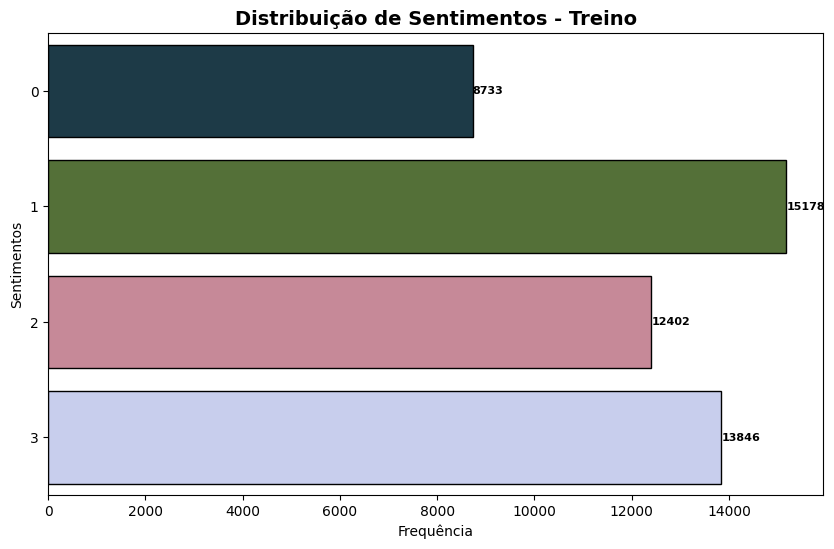

In [33]:
# Visualizando a distribuição dos dados do y_train
plot_sentiment_distribution(y_train, title='Distribuição de Sentimentos - Treino')

Visualizando a distribuição dos dados do *y_test*

<ipython-input-32-f38c460ba5ba>:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




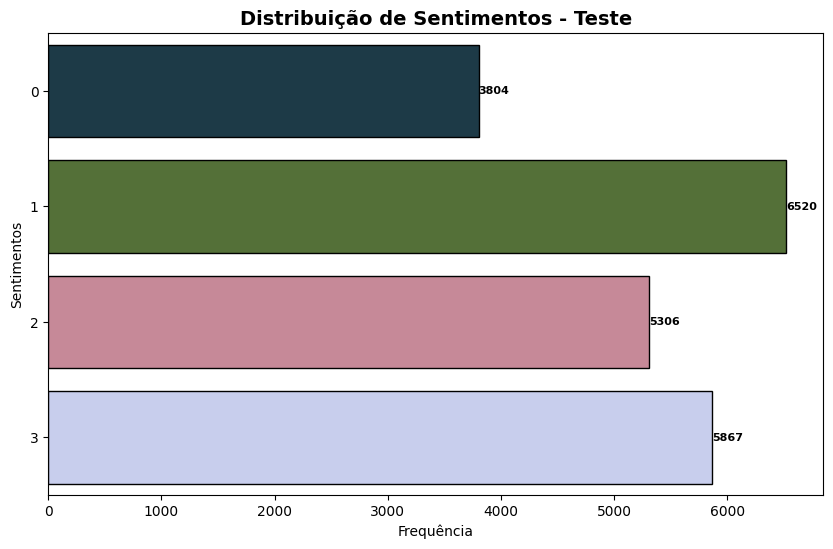

In [34]:
# Visualizando a distribuição dos dados do y_test
plot_sentiment_distribution(y_test, title='Distribuição de Sentimentos - Teste')

Abaixo importamos e configuramos várias bibliotecas e modelos de classificação (DecisionTree, RandomForest, ExtraTrees) para realizar a tarefa de classificação em um conjunto de dados. Ele define uma semente para reprodutibilidade, inicializa os modelos com parâmetros específicos, treina-os usando um conjunto de dados de treinamento e avalia seu desempenho utilizando a acurácia balanceada nos conjuntos de treinamento e teste. O progresso do treinamento é monitorado com uma barra de progresso tqdm, e os resultados são impressos para cada modelo, facilitando a comparação de suas performances.








In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (balanced_accuracy_score,
                             confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             classification_report,
                             f1_score,
                             ConfusionMatrixDisplay
                             )

from collections import Counter
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')


Abaixo importamos várias bibliotecas e modelos de classificação (DecisionTree, RandomForestClassifier e ExtraTreesClassifier) para realizar a tarefa de análise de sentimento. Definimos uma semente para reprodutibilidade e utilizamos a biblioteca `tqdm` para monitorar o progresso durante o treinamento dos modelos.

**Argumentação Técnica para RandomForestClassifier e ExtraTreesClassifier:**

Selecionamos os modelos `RandomForestClassifier` e `ExtraTreesClassifier` devido à sua robustez e bom desempenho em tarefas de classificação, especialmente com dados textuais vetoriais (TF-IDF). Ambos são métodos de ensemble baseados em árvores de decisão que ajudam a reduzir o overfitting e a variância.

-   **RandomForestClassifier:** Constrói múltiplas árvores de decisão durante o treinamento e produz a classe que é a moda das classificações das árvores individuais. Incorpora bagging e randomização de features, tornando-o menos propenso a overfitting e geralmente fornecendo boa acurácia. [Referência: scikit-learn documentation [3], didatica.tech [4]]
-   **ExtraTreesClassifier:** Similar ao RandomForest, mas com uma randomização adicional na seleção dos pontos de divisão nas árvores. Isso geralmente leva a árvores menos correlacionadas e pode melhorar o desempenho em alguns casos.

Apesar de termos importado `DecisionTreeClassifier`, nosso foco inicial e a comparação de desempenho se darão entre `RandomForestClassifier` e `ExtraTreesClassifier` por suas características de ensemble que tendem a ser mais eficazes para este tipo de problema.

É notável que destacam-se dois modelos :     

1)  RandomForestClassifier | Acc Train: 0.9836 | Acc Test: 0.9305

2)  ExtraTreesClassifier | Acc Train: 0.9836 | Acc Test: 0.9358

In [36]:
SEED = 42 # Definindo uma semente para reprodutibilidade

# Inicializando os modelos com a semente e configurando para usar todos os cores da CPU
dt = DecisionTreeClassifier(random_state = SEED)
rf = RandomForestClassifier(random_state = SEED, n_jobs = -1)
ets = ExtraTreesClassifier(random_state = SEED, bootstrap = True, n_jobs = -1)

# Criando uma lista com os modelos a serem treinados
MODELS = [dt, rf, ets]

# Iterando sobre cada modelo na lista com uma barra de progresso (tqdm)
for model in tqdm(MODELS):
    name = type(model).__name__ # Obtendo o nome do modelo
    model.fit(X_train, y_train) # Treinando o modelo com os dados de treino
    y_pred_train = model.predict(X_train) # Fazendo previsões nos dados de treino
    y_pred_test = model.predict(X_test)   # Fazendo previsões nos dados de teste

    # Imprimindo a acurácia balanceada nos conjuntos de treino e teste
    print(f"* {name} | Acc Train: {balanced_accuracy_score(y_train, y_pred_train):.4f} | Acc Test: {balanced_accuracy_score(y_test, y_pred_test):.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

* DecisionTreeClassifier | Acc Train: 0.9837 | Acc Test: 0.8100
* RandomForestClassifier | Acc Train: 0.9836 | Acc Test: 0.9309
* ExtraTreesClassifier | Acc Train: 0.9836 | Acc Test: 0.9358


###Implementação do modelo RandomForestClassifier

In [37]:
# Implementando o modelo RandomForestClassifier com os parâmetros definidos
rf = RandomForestClassifier(random_state = SEED, n_jobs = -1)

Treinamento do Modelo Ramdom

In [38]:
#Treinamento do Modelo
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Previsão e verificando a accuracy do modelo

A acurácia é uma métrica de avaliação que mede a proporção de previsões corretas feitas pelo modelo em relação ao total de previsões.

Neste caso, a acurácia de aproximadamente 0.9345 significa que o modelo RandomForestClassifier acertou cerca de 93.45% das classificações de sentimento no conjunto de teste. É uma métrica útil para ter uma ideia geral do desempenho do modelo, mas é importante analisar outras métricas, como precisão e recall, especialmente em problemas com classes desbalanceadas.

In [39]:
# Realizando previsões no conjunto de teste usando o modelo RandomForest
y_test_rf = rf.predict(X_test)

# Calculando a acurácia do modelo no conjunto de teste
test_accuracy_rf = accuracy_score(y_test, y_test_rf)

# Exibindo a acurácia calculada
test_accuracy_rf

0.9345024887193562

Métricas do modelo

É importante explicar que essas métricas são fundamentais para entender o desempenho do modelo

O trecho de código apresentado exibe métricas de avaliação para um modelo de classificação, detalhando a performance em termos de precisão, recall e F1-Score para cada classe. A precisão indica a proporção de predições corretas entre todas as predições positivas feitas pelo modelo. O recall mede a capacidade do modelo de identificar corretamente todas as amostras positivas reais. O F1-Score é a média harmônica entre precisão e revocação, proporcionando uma métrica única que balanceia ambas.

É importante explicar que essas métricas são fundamentais para entender o desempenho do modelo. Por exemplo, para a classe 0, observamos uma precisão de 0.96, recall de 0.90 e F1-score de 0.93. Isso significa que, para a classe 0:

*   **Precisão (0.96):** 96% dos tweets classificados como classe 0 pelo modelo realmente pertencem à classe 0.
*   **Recall (0.90):** O modelo identificou corretamente 90% de todos os tweets que são da classe 0.
*   **F1-Score (0.93):** Uma métrica balanceada que considera tanto a precisão quanto o recall para a classe 0.

In [40]:
print(classification_report(y_test, y_test_rf))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      3804
           1       0.93      0.95      0.94      6520
           2       0.94      0.93      0.94      5306
           3       0.91      0.94      0.93      5867

    accuracy                           0.93     21497
   macro avg       0.94      0.93      0.93     21497
weighted avg       0.94      0.93      0.93     21497



Matriz de Confusão do Ramdom

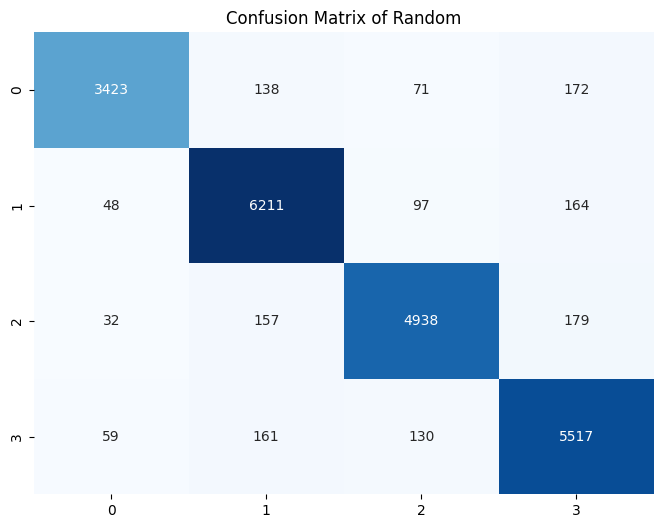

In [41]:
from sklearn.metrics import confusion_matrix
# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix of Random')
plt.show()

### Implementação do modelo ExtraTreesClassifier

In [42]:
# Implementando o modelo ExtraTressClassifier com os parâmetros definidos
ets = ExtraTreesClassifier(random_state = SEED, bootstrap = True, n_jobs = -1)

Treinamento do modelo Extra

In [43]:
#Treinamento do Modelo
ets.fit(X_train, y_train)

ExtraTreesClassifier(bootstrap=True, n_jobs=-1, random_state=42)

Previsão e verificando a accuracy do modelo

A acurácia é uma métrica de avaliação que mede a proporção de previsões corretas feitas pelo modelo em relação ao total de previsões.

Neste caso, a acurácia de aproximadamente 0.9397 significa que o modelo RandomForestClassifier acertou cerca de 93.97% das classificações de sentimento no conjunto de teste. É uma métrica útil para ter uma ideia geral do desempenho do modelo, mas é importante analisar outras métricas, como precisão e recall, especialmente em problemas com classes desbalanceadas.

In [44]:
# Realizando previsões no conjunto de teste usando o modelo ExtraTress
y_test_ets = ets.predict(X_test)

# Calculando a acurácia do modelo no conjunto de teste
test_accuracy_ets = accuracy_score(y_test, y_test_ets)

# Exibindo a acurácia calculada
test_accuracy_ets

0.9397590361445783

Métricas do modelo

O trecho de código apresentado exibe métricas de avaliação para um modelo de classificação, detalhando a performance em termos de precisão, recall e F1-Score para cada classe. A precisão indica a proporção de predições corretas entre todas as predições positivas feitas pelo modelo. O recall mede a capacidade do modelo de identificar corretamente todas as amostras positivas reais. O F1-Score é a média harmônica entre precisão e revocação, proporcionando uma métrica única que balanceia ambas.

É importante explicar que essas métricas são fundamentais para entender o desempenho do modelo. Por exemplo, para a classe 0, observamos uma precisão de 0.97, recall de 0.90 e F1-score de 0.93. Isso significa que, para a classe 0:

*   **Precisão (0.97):** 97% dos tweets classificados como classe 0 pelo modelo realmente pertencem à classe 0.
*   **Recall (0.90):** O modelo identificou corretamente 90% de todos os tweets que são da classe 0.
*   **F1-Score (0.93):** Uma métrica balanceada que considera tanto a precisão quanto o recall para a classe 0.

In [45]:
print(classification_report(y_test, y_test_ets))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      3804
           1       0.94      0.96      0.95      6520
           2       0.95      0.94      0.94      5306
           3       0.92      0.95      0.93      5867

    accuracy                           0.94     21497
   macro avg       0.94      0.94      0.94     21497
weighted avg       0.94      0.94      0.94     21497



Matriz de Confusão do Extra

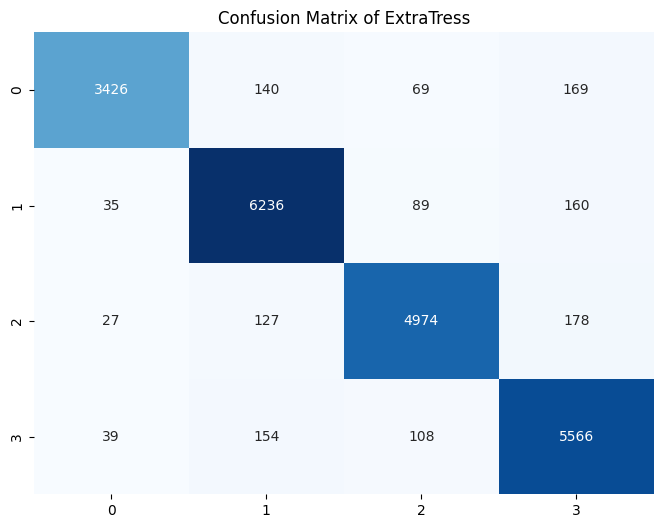

In [46]:
from sklearn.metrics import confusion_matrix
# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_ets)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix of ExtraTress')
plt.show()

###Resultados dos Modelos

In [47]:
import pandas as pd
metrics ={
    'Model':['Random Forest', 'ExtraTreesClassifier'],
    'Accuracy': [test_accuracy_rf,test_accuracy_ets],
    'Precision 0': [precision_score(y_test, y_test_rf, pos_label=0, average='weighted'),precision_score(y_test, y_test_ets, pos_label=0, average='weighted')],
    'Precision 1': [precision_score(y_test, y_test_rf, pos_label=1, average='weighted'),precision_score(y_test, y_test_ets, pos_label=1, average='weighted')],
    'Precsion 2': [precision_score(y_test, y_test_rf, pos_label=2, average='weighted'),precision_score(y_test, y_test_ets, pos_label=2, average='weighted')],
    'Precsion 3': [precision_score(y_test, y_test_rf, pos_label=3, average='weighted'),precision_score(y_test, y_test_ets, pos_label=3, average='weighted')],
    'Recall 0': [recall_score(y_test, y_test_rf, pos_label=0, average='weighted'),recall_score(y_test, y_test_ets, pos_label=0, average='weighted')],
    'Recall 1': [recall_score(y_test, y_test_rf, pos_label=1, average='weighted'),recall_score(y_test, y_test_ets, pos_label=1, average='weighted')],
    'Recall 2': [recall_score(y_test, y_test_rf, pos_label=2, average='weighted'),recall_score(y_test, y_test_ets, pos_label=2, average='weighted')],
    'Recall 3': [recall_score(y_test, y_test_rf, pos_label=3, average='weighted'),recall_score(y_test, y_test_ets, pos_label=3, average='weighted')],
}
metrics = pd.DataFrame(metrics)

Abaixo possui as métricas dos modelos treinado, percebe-se que os dois modelos possuem semelhanças nos resultados

In [48]:
metrics.head()

,Model,Accuracy,Precision 0,Precision 1,Precsion 2,Precsion 3,Recall 0,Recall 1,Recall 2,Recall 3
0,Random Forest,0.934502,0.935001,0.935001,0.935001,0.935001,0.934502,0.934502,0.934502,0.934502
1,ExtraTreesClassifier,0.939759,0.940437,0.940437,0.940437,0.940437,0.939759,0.939759,0.939759,0.939759


Salvando os Modelos para validação de um novo Dataset

In [49]:
import joblib
joblib.dump(rf, 'random_forest.pkl')
joblib.dump(ets, 'extra_tress.pkl')

['extra_tress.pkl']

### Validação dos Modelos

In [50]:
#Importando novo Dataset
df_validation = pd.read_csv('twitter_validation.csv',names=cols)
df_validation.head()

,tweetid,entity,target,content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


###  Distribuição Real das Classes

Antes de avaliar o modelo, vale lembrar a distribuição original no conjunto de validação:

| Sentimento  | Ocorrências | Porcentagem |
|-------------|-------------|-------------|
| Neutral     | 285         | 28.5%       |
| Positive    | 277         | 27.7%       |
| Negative    | 266         | 26.6%       |
| Irrelevant  | 172         | 17.2%       |
| **Total**   | **1000**    | **100%**    |

In [51]:
df_validation['target'].value_counts()

,count
target,
Neutral,285
Positive,277
Negative,266
Irrelevant,172


###  Carregamento dos Dados de Validação

Antes de aplicar o modelo treinado ao conjunto de validação, definimos os caminhos dos arquivos necessários para o processamento:

- `df_twiiter_validation`: Nome do arquivo CSV contendo os dados de validação extraídos do Kaggle.
- `validation_csv_path`: Caminho para o arquivo `.csv` com os tweets a serem validados.
- `vectorizer_path`: Caminho para o vetor TF-IDF salvo anteriormente durante o treinamento.
- `label_encoder_path`: Caminho para o codificador (`LabelEncoder`) salvo, responsável por transformar os rótulos originais em valores numéricos.

Essas variáveis serão utilizadas como entrada na função `process_validation_data()`, que realiza o seguinte:

- Carrega o dataset de validação com as colunas definidas;
- Aplica o mesmo pré-processamento de texto utilizado no treino;
- Transforma o texto em vetores TF-IDF com o `vectorizer` salvo;
- Codifica as classes reais com o `LabelEncoder`.

In [52]:
df_twiiter_validation = 'twitter_validation.csv'
validation_csv_path = 'twitter_validation.csv'
vectorizer_path = 'tfidf_vectorizer.pkl'
label_encoder_path = 'label_encoder.pkl'

## O que a função `process_validation_data()` faz?

Essa função tem um papel muito importante no projeto: ela **prepara os dados que serão testados** (validação) para que possam ser lidos corretamente pelo modelo de inteligência artificial que já foi treinado.

---

###  O que essa função recebe:

Ela precisa de 4 coisas:

1. **`validation_csv_path`**: o caminho (nome do arquivo) onde estão os dados a serem testados — como tweets e seus sentimentos reais.
2. **`vectorizer_path`**: o arquivo que guarda o "tradutor" de texto para números (chamado vetorizador TF-IDF).
3. **`label_encoder_path`**: o arquivo que guarda a tradução dos sentimentos (como 'Positive' → 3).
4. **`cols`**: a lista com os nomes das colunas da tabela de dados (como `tweetid`, `content`, `target`, etc).

---

###  Passo a passo do que acontece

1. **Carrega a tabela com os tweets de validação** (arquivo CSV).
2. **Remove colunas que não são úteis**, como o `tweetid`.
3. **Limpa o texto dos tweets** (tira pontuações, deixa minúsculo, remove palavras comuns etc.).
4. **Junta o conteúdo do tweet com a empresa mencionada**, para dar mais contexto ao modelo.
5. **Traduz o texto para números** usando o mesmo “tradutor” que foi usado quando o modelo foi treinado (TF-IDF).
6. **Traduz os sentimentos (alvo)** como 'Positive', 'Neutral', etc., para números — para que o modelo consiga comparar e aprender.

---

### 🧾 O que a função devolve (retorna)

Ela devolve 3 coisas:

- **`X_validation`** → Os textos já transformados em números.
- **`Y_validation_encoded`** → As respostas corretas (sentimentos), também em forma numérica.
- **`df_validation`** → A tabela original, já limpa e pronta para análise.

In [53]:
def process_validation_data(validation_csv_path, vectorizer_path, label_encoder_path, cols):
    """
    Carrega, pré-processa e transforma o dataset de validação.

    Args:
        validation_csv_path (str): Caminho para o arquivo CSV do dataset de validação.
        vectorizer_path (str): Caminho para o arquivo .pkl do vetorizador TF-IDF treinado.
        label_encoder_path (str): Caminho para o arquivo .pkl do LabelEncoder treinado.
        cols (list): Lista com os nomes das colunas do dataset.

    Returns:
        tuple: Uma tupla contendo:
               - X_validation: Features transformadas do conjunto de validação (matriz TF-IDF).
               - Y_validation_encoded: Rótulos transformados (numéricos) do conjunto de validação.
               - df_validation: O DataFrame de validação processado.
    """
    # Carregar o dataset de validação
    df_validation = pd.read_csv(validation_csv_path, names=cols)

    # Remover a coluna 'tweetid'
    df_validation.drop(columns=['tweetid'], axis=1, inplace=True)

    # Aplicar a função de pré-processamento textual na coluna 'content'
    # Certifique-se de que a função preprocess_text está definida globalmente ou importada
    df_validation['content'] = df_validation['content'].apply(preprocess_text)

    # Combinar as colunas 'content' e 'entity'
    df_validation['text_combined'] = df_validation['content'] + ' ' + df_validation['entity']

    # Carregar o vetorizador TF-IDF treinado
    vectorizer = joblib.load(vectorizer_path)

    # Transformar os dados de validação usando o vetorizador TF-IDF (APENAS TRANSFORM)
    X_validation = vectorizer.transform(df_validation['text_combined'])

    # Carregar o LabelEncoder treinado
    label_encoder = joblib.load(label_encoder_path)

    # Transformar os rótulos de validação usando o LabelEncoder (APENAS TRANSFORM)
    Y_validation = df_validation['target'].values
    Y_validation_encoded = label_encoder.transform(Y_validation)

    return X_validation, Y_validation_encoded, df_validation

Aplicação da Função

In [54]:
# Aplicação e Saídas das função "process_validation_data"
X_validation, Y_validation_encoded, df_validation = process_validation_data(validation_csv_path, vectorizer_path, label_encoder_path, cols)

Visualizando as Dimensões das Saídas

In [55]:
print(f'X_Validation : {X_validation.shape}')
print(f'Y_validation : {Y_validation_encoded.shape}')
print(f'df_twiiter_validation : {df_validation.shape}')

X_Validation : (1000, 25429)
Y_validation : (1000,)
df_twiiter_validation : (1000, 4)


##  Carregamento dos Modelos de Validação

Antes de aplicar o modelo treinado ao conjunto de validação, definimos os caminhos dos arquivos necessários para o processamento:

- `rf_validation`: Caminho para o Modelo (`Random Forest`) salvo.
- `ets_validation`: Caminho para o Modelo (`ExtraTress`) salvo.

Essas variáveis serão utilizadas como entrada na função `evaluate_model_on_valida()`, que realiza o seguinte:


In [56]:
#Carregando os Modelos
rf_validation = 'random_forest.pkl'
ets_validation = 'extra_tress.pkl'

##  Avaliação de Modelos com Dados de Validação

A função `evaluate_model_on_validation()` serve para **testar um modelo de inteligência artificial já treinado** com dados novos (de validação), e **mostrar o desempenho dele de forma visual e numérica**.

---

###  O que essa função faz:

1. **Carrega o modelo e o LabelEncoder salvos** do disco.
2. **Faz previsões** com os tweets de validação (`X_val`).
3. **Compara as previsões com as respostas reais (`y_val`)**.
4. Calcula as **principais métricas**:
   - Acurácia
   - Precisão
   - Recall
   - F1-score
5. Gera a **matriz de confusão** com rótulos verdadeiros e previstos.
6. Exibe tudo de forma clara com gráficos e tabelas.

---

###  Parâmetros de entrada:

| Parâmetro          | Descrição                                                                 |
|--------------------|---------------------------------------------------------------------------|
| `model`            | Caminho para o arquivo do modelo salvo (`.pkl`)                           |
| `X_val`            | Tweets de validação transformados (vetorizados)                           |
| `y_val`            | Rótulos verdadeiros da validação (em formato numérico)                    |
| `label_encoder_path`| Caminho para o arquivo `.pkl` do `LabelEncoder` usado no treino          |
| `model_name`       | Nome do modelo (apenas para exibir no gráfico)                            |

---

###  Retorno da função:

A função devolve:
- Um **DataFrame com as métricas** principais: accuracy, precision, recall, F1.
- O **classification report completo** do `sklearn`, com métricas por classe.





In [57]:
def evaluate_model_on_validation(model, X_val, y_val,label_encoder_path, model_name):
    """
    Avalia um modelo treinado em um conjunto de dados de validação.

    Args:
        model: O modelo treinado.
        X_val: Features do conjunto de validação.
        y_val: Rótulos do conjunto de validação (numéricos/codificados).
        model_name (str): O nome do modelo para exibição nos gráficos/relatórios.

    Returns:
        dict: Um dicionário contendo as métricas de avaliação (accuracy, precision, recall, f1-score, confusion matrix, classification report).
    """
    label_encoder = joblib.load(label_encoder_path)
    model = joblib.load(model)
    y_pred_val = model.predict(X_val)
    classes = label_encoder.classes_

    # Calcular métricas
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val, average='weighted')
    recall = recall_score(y_val, y_pred_val, average='weighted')
    f1 = f1_score(y_val, y_pred_val, average='weighted')
    cm = confusion_matrix(y_val, y_pred_val)
    report = classification_report(y_val, y_pred_val)


    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, display_labels=classes, cmap='Blues')
    plt.title(f'Matriz de Confusão - {model_name} of Validation')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    """# Plotar matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix - {model_name} Validation')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()"""

    # Retornar métricas
    metrics = {
        'accuracy': [accuracy],
        'precision (weighted)': [precision],
        'recall (weighted)': [recall],
        'f1-score (weighted)': [f1],
    }

    metrics = pd.DataFrame(metrics)

    return metrics, classification_report(y_val, y_pred_val)

## Análise do Modelo Random Forest

### **negrito** Análise da Matriz de Confusão

| Tipo de erro                         | Qtde | Impacto                                  |
|--------------------------------------|------|-------------------------------------------|
| Irrelevant → Negative/Neutral/Positive | 11   | 6.4% dos casos de "Irrelevant" foram confundidos |
| Neutral → Negative/Positive            | 12   | 4.2% dos "Neutral" foram confundidos       |
| Positive → Neutral/Negative            | 14   | 5.1% dos "Positive" foram mal classificados |
| Negative → Positive/Neutral            | 7    | 2.6% de erro                              |

📉 Classes **Neutral e Positive** tendem a se confundir mais entre si.

<Figure size 800x600 with 0 Axes>

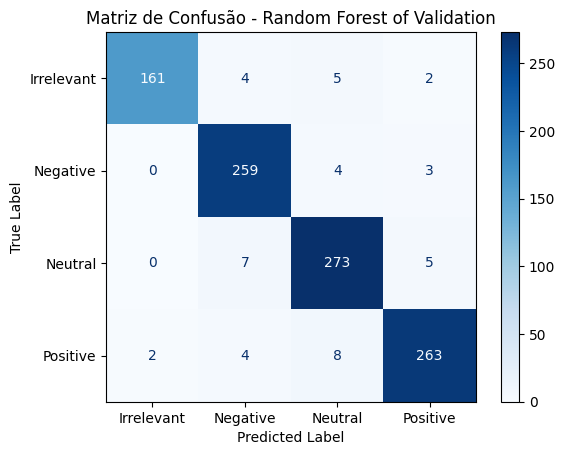

In [58]:
#Aplicação do Função que vai exibir as evoluções do Random Forest
metrics_rf, classification_report_rf = evaluate_model_on_validation(rf_validation, X_validation, Y_validation_encoded,label_encoder_path, 'Random Forest')

### Desempenho Geral (Random Forest)

| Métrica              | Valor    |
|----------------------|----------|
| Accuracy             | **95.6%** |
| Precision (weighted) | 95.6%    |
| Recall (weighted)    | 95.6%    |
| F1-score (weighted)  | 95.6%    |

O modelo apresenta **alta acurácia geral**, com excelente equilíbrio entre precisão e recall nas classes.

In [59]:
#Métricas dos Modelos Random Forest
metrics_rf

,accuracy,precision (weighted),recall (weighted),f1-score (weighted)
0,0.956,0.956474,0.956,0.956027


### 📌 Desempenho por Classe

| Classe      | Precision | Recall | F1-score | Suporte | Observação |
|-------------|-----------|--------|----------|---------|------------|
| Irrelevant  | **0.99**  | 0.94   | 0.96     | 172     | Alta precisão, recall levemente menor – há falsos negativos |
| Negative    | 0.95      | **0.97**| 0.96     | 266     | Classificações muito corretas, poucos falsos positivos |
| Neutral     | 0.94      | **0.96**| 0.95     | 285     | Alta sensibilidade, boa cobertura da classe |
| Positive    | 0.96      | 0.95   | 0.96     | 277     | Equilíbrio ideal entre precisão e recall |

In [60]:
#Desempenho das Classes
print(classification_report_rf)

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       172
           1       0.95      0.97      0.96       266
           2       0.94      0.96      0.95       285
           3       0.96      0.95      0.96       277

    accuracy                           0.96      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.96      0.96      0.96      1000



### Conclusão do Random Forest

####  Pontos Fortes do Modelo
- Excelente desempenho nas 4 classes principais com F1 acima de 0.95.
- Poucos erros graves de confusão cruzada.
- Modelo escalável e eficiente para textos vetorizados.

---

#### Elos Fracos / Oportunidades de Melhoria
- O modelo ainda comete cerca de 4 a 6% de erros por classe.
- Pode ser mais robusto com **lematização** ou modelos como **BERT**.
- Sugestões de incremento:
  - Ajuste de hiperparâmetros com GridSearch
  - Word Embeddings (GloVe, FastText)
  - Balanceamento com oversampling

---

####  Conclusão Final

> O modelo Random Forest apresentou desempenho excelente na tarefa de classificação de sentimentos, com métricas consistentes e erros baixos. Apesar de pequenas confusões entre classes subjetivamente próximas, ele está pronto para uso real e pode ser facilmente integrado a um sistema de análise de sentimentos, com potencial de melhora por meio de vetores semânticos e técnicas modernas de PLN.


## Análise do Modelo ExtraTress

###  Análise da Matriz de Confusão

| Tipo de erro                         | Qtde | Impacto                                  |
|--------------------------------------|------|-------------------------------------------|
| Irrelevant → outras classes           | 10   | 5.8% dos "Irrelevant" foram confundidos   |
| Positive → outras                     | 13   | 4.7% de erro entre Positive e Negative    |
| Neutral → outras                      | 8    | 2.8% confundidos com outras               |
| Negative → outras                     | 7    | 2.6% de erro                              |

📉 Erros ligeiramente menores que o Random Forest, com melhor separação das classes **Positive** e **Neutral**.

<Figure size 800x600 with 0 Axes>

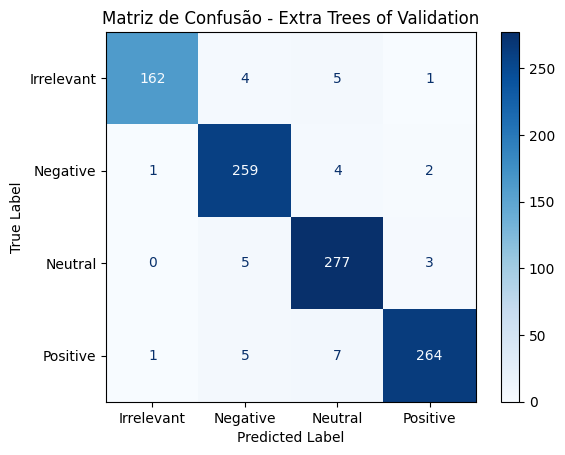

In [61]:
#Aplicação do Função que vai exibir as evoluções do Modelo Extratress
metrics_ets, classification_report_ets = evaluate_model_on_validation(ets_validation, X_validation, Y_validation_encoded,label_encoder_path, 'Extra Trees')

### 🧠 Desempenho Geral (Extra Trees)

| Métrica              | Valor    |
|----------------------|----------|
| Accuracy             | **96.2%** |
| Precision (weighted) | 96.3%    |
| Recall (weighted)    | 96.2%    |
| F1-score (weighted)  | 96.2%    |

O modelo Extra Trees superou ligeiramente o Random Forest, mantendo equilíbrio entre precisão e recall e demonstrando robustez na classificação das 4 categorias.

In [62]:
#Metricas do ExtraTress
metrics_ets

,accuracy,precision (weighted),recall (weighted),f1-score (weighted)
0,0.962,0.962543,0.962,0.962038


### Desempenho por Classe

| Classe      | Precision | Recall | F1-score | Suporte | Observação |
|-------------|-----------|--------|----------|---------|------------|
| Irrelevant  | **0.99**  | 0.94   | 0.96     | 172     | Excelência em precisão, mas com leve perda em recall (alguns falsos negativos) |
| Negative    | 0.95      | **0.97**| 0.96     | 266     | Desempenho muito sólido, com altíssima cobertura |
| Neutral     | 0.95      | **0.97**| 0.96     | 285     | Modelo captura muito bem essa classe |
| Positive    | **0.98**  | 0.95   | 0.97     | 277     | Ótimo equilíbrio e destaque em precisão |

In [63]:
#Desempenho das Classes
print(classification_report_ets)

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       172
           1       0.95      0.97      0.96       266
           2       0.95      0.97      0.96       285
           3       0.98      0.95      0.97       277

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



### Conclusão do Modelo ExtraTress

####  Pontos Fortes do Modelo
- Métrica F1 consistentemente alta (≥ 0.96) para todas as classes.
- Melhor separação entre classes semelhantes (Neutral e Positive).
- Excelente desempenho geral, sendo um dos melhores modelos da avaliação.

---

####  Elos Fracos / Oportunidades de Melhoria
- Pequena confusão ainda entre classes subjetivamente próximas.
- Como é um modelo ensemble, pode ser mais pesado computacionalmente.
- Potencial de reforço com embeddings ou modelos semânticos mais profundos (BERT, RoBERTa).

---

####  Conclusão Final

> O modelo Extra Trees demonstrou performance excepcional em classificação de sentimentos com PLN. Com métricas superiores a 96% em todas as dimensões e erros muito controlados, ele se apresenta como uma das melhores opções para deploy imediato, mantendo precisão, robustez e generalização.



#  Conclusão Final

Percebe-se que esse dataframe possui quatro classes de sentimentos: *Neutro*, *Irrelevante*, *Positivo* e *Negativo*. Determinados modelos conseguiram prever essas quatro classes com excelentes resultados, como mostrado nas avaliações do Random Forest e do Extra Trees.

O modelo **Random Forest** alcançou uma acurácia de **95.6%**, enquanto o **Extra Trees** obteve **96.2%**, com métricas de F1-score, precisão e recall consistentemente acima de 0.95 para todas as classes. Isso indica que ambos os modelos são altamente confiáveis para classificar sentimentos em textos do Twitter, com destaque para o Extra Trees em termos de precisão nas classes *Positive* e *Neutral*.

A análise da matriz de confusão revelou que as maiores confusões ocorrem entre as classes *Neutral* e *Positive*, o que é esperado em tarefas de PLN, dado o conteúdo subjetivo e o tom ambíguo de muitos comentários. Apesar disso, os erros são relativamente baixos e não comprometem a performance geral do modelo.

### 🎯 Observações Estratégicas

Para fins de negócio, é viável considerar a **redução das quatro classes para duas**, agrupando *Neutral* e *Irrelevante* como *Não-Negativas*, e mantendo apenas *Positivo* e *Negativo*. Isso porque:
- Comentários neutros, em muitos contextos, não indicam insatisfação e podem ser tratados como *comentários aceitáveis*.
- Comentários irrelevantes podem conter ruídos que não agregam valor à análise estratégica.

Essa **redefinição de classes** deve ser guiada pelos objetivos do projeto: se o foco for monitoramento de crise, priorizar *Negativo* vs *Não-Negativo* pode ser mais eficaz. Se o objetivo for análise de satisfação, manter as quatro classes pode enriquecer a granularidade.

---

Este projeto demonstra a aplicação de **aprendizado de máquina** em um problema real de **processamento de linguagem natural (PLN)**, utilizando dados da plataforma Kaggle: [Análise de sentimento do Twitter](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis/code). Os modelos foram validados com rigor e estão prontos para serem integrados em pipelines de análise automatizada de sentimentos com potencial para dashboard, APIs ou interfaces interativas com Streamlit.

